[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/navjotts/ML-experiments/blob/master/13%20-%20Linear%20Regression%20using%20Gradient%20Descent/Linear_Regression_using_Gradient_Descent.ipynb)

# Data

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:4: RuntimeWarning: covariance is not positive-semidefinite.
  after removing the cwd from sys.path.


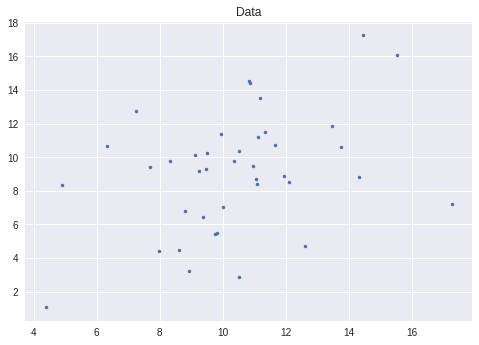

In [4]:
import numpy as np
import matplotlib.pyplot as plt

points = np.random.multivariate_normal([10, 10], [[10, 10], [0, 10]], 40)
x, y = points.T
plt.plot(x, y, '.')
plt.title('Data');

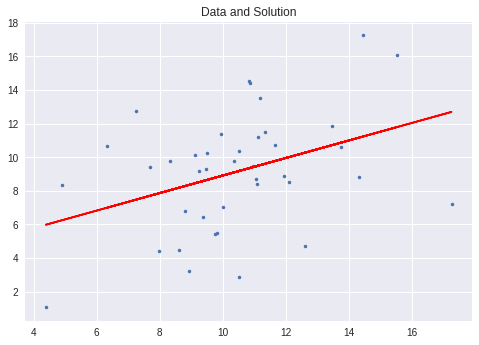

In [6]:
solution = np.polyfit(x, y, 1)
plt.plot(x, y, '.')
plt.plot(x, x*solution[0] + solution[1], c='r');
plt.title('Data and Solution');

### Root-mean Squared Error (RMSE)

RMSE is the one of most common "loss function", that is, a way of measuring the error in a model prediction. The error of a prediction is the difference between the values it predicted and the values that were expected.

RMSE is calculated:

$RMSE = \sqrt{\frac{\sum_{t=1}^T \left( \hat{y_t} - y_t \right) ^2}{T}}$

$\hat{y_t}$ is the prediction of the model for a particular sample $t$. $y_t$ is the true label for sample $t$.

Linear regression is the proess of minimizing the least-squared error between the line-of-regression and the sample points.


In [33]:
coefficients, residual, solution_rank, solution_singular_values, rcond_epsilon = np.polyfit(x, y, 1, full=True)
print('coefficients:', coefficients)
print('SSE:', residual[0])
print('MSE:', residual[0]/len(y))
print('RMSE:', np.sqrt(residual[0]/len(y)))

coefficients: [0.5216 3.6898]
SSE: 417.43314627082185
MSE: 10.435828656770546
RMSE: 3.230453320630178


Confirm residual is SSE

In [0]:
assert np.round(np.sum((x*coefficients[0] + coefficients[1] - y)**2), 3) == np.round(residual, 3)

# Problem Statement
Goal here is to minmize the loss function (MSE or RMSE), in order to find the optimal solution.

### Let's plot what are we trying to do here

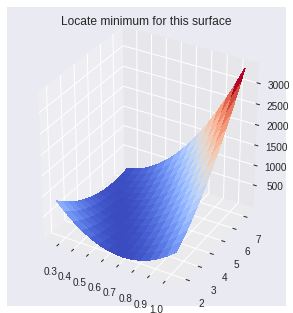

In [22]:
from mpl_toolkits.mplot3d.axes3d import Axes3D
from matplotlib import cm

def mse(x, prediction_m, prediction_b, true_m, true_b):
  width = len(prediction_m)
  height = len(prediction_m[0])
  result = np.zeros(width*height).reshape(width, height)
  for row in range(width):
    for col in range(height):      
      m = prediction_m[row][col]
      b = prediction_b[row][col]
      result[row][col] = np.sum(((x*m+b)-(x*true_m+true_b))**2)
  return result

m_range = np.linspace(coefficients[0]*0.5, 2*coefficients[0], 15)
b_range = np.linspace(coefficients[1]*0.5, 2*coefficients[1], 15)
mm, bb = np.meshgrid(m_range, b_range)
Z = mse(x, mm, bb, coefficients[0], coefficients[1])

fig = plt.figure(figsize=plt.figaspect(0.5))
ax = fig.add_subplot(1, 2, 1, projection='3d')
surf = ax.plot_surface(mm, bb, Z, cmap=cm.coolwarm, linewidth=0, antialiased=False)
ax.set_title('Locate minimum for this surface');

# Gradient Descent

The error function $E_{rms} = \sum{\sqrt{(\hat y_i - y_i)^2}}$ is differentiable: that is, we can find the derivative of the error function, which informs us how to update the parameters to minimize it.

Lets drop the $\sqrt{}$ to make the derivative easier:

$E_{rms} = \sum{(\hat y_i - y_i)^2} = \sum{(mx_i + b - y_i)^2}$


We have two variables $m$ and $b$ that we'd like to solve for, and 2 derivatives at our disposal respectively:

$\frac{\partial}{\partial m} = -2\sum x(mx_i + b - y)$

$\frac{\partial}{\partial b} = -2\sum (mx_i + b - y)$


---

### Gradient Descent Algorithm

*   gradient (or derivative) = rate of change
*   We want to minimize the loss - we are looking for an optima (gradient = 0) – i.e. how should we change a var, such that the loss minimizes
*   We want to move in the direction opposite to the gradient (if the rate of change is positive, we want to decrease it – if the rate of change is negative, we want to increase it)
*   in short, `new_var = old_var - (gradient * learning_rate)` (where `learning_rate` decides how big of a step we take in each iteration)



====================> epoch=300 	 m_current:0.82698 	 b_current:0.31738 	 loss:11.09402
====================> epoch=600 	 m_current:0.80665 	 b_current:0.54188 	 loss:11.00931
====================> epoch=900 	 m_current:0.78767 	 b_current:0.75144 	 loss:10.93549
====================> epoch=1200 	 m_current:0.76995 	 b_current:0.94705 	 loss:10.87118
====================> epoch=1500 	 m_current:0.75342 	 b_current:1.12964 	 loss:10.81515
====================> epoch=1800 	 m_current:0.73798 	 b_current:1.30007 	 loss:10.76633
====================> epoch=2100 	 m_current:0.72358 	 b_current:1.45916 	 loss:10.72379
====================> epoch=2400 	 m_current:0.71013 	 b_current:1.60765 	 loss:10.68672
====================> epoch=2700 	 m_current:0.69758 	 b_current:1.74626 	 loss:10.65443
coefficients: 0.6858616907552418 1.8756440201929852
MSE: 10.626381979750116


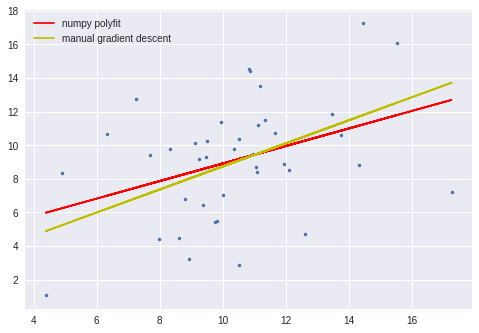

In [36]:
def linear_regression(X, y, m_current=0, b_current=0, epochs=3000, learning_rate=0.002):
  N = float(len(y))
  for i in range(epochs):
    y_current = (m_current * X) + b_current
    loss = sum([data**2 for data in (y-y_current)]) / N
    
    if i%(epochs/10)==0 and i>0:
      print(f'====================> epoch={i} \t m_current:{np.round(m_current, 5)} \t b_current:{np.round(b_current, 5)} \t loss:{np.round(loss, 5)}')
        
    m_gradient = -(2/N) * sum(X * (y - y_current))    
    b_gradient = -(2/N) * sum(y - y_current)
    m_current = m_current - (learning_rate * m_gradient)
    b_current = b_current - (learning_rate * b_gradient)
    
  return m_current, b_current, loss

m, b, loss = linear_regression(x, y)
print('coefficients:', m, b)
print('MSE:', loss)
plt.plot(x, y,'.')
plt.plot(x, x*solution[0]+solution[1], c='r', label='numpy polyfit')
plt.plot(x, x*m+b, c='y', label='manual gradient descent')
plt.legend();

**Observation:** Not that bad, numpy's polyfit gave `MSE: 10.435828656770546`

# Multivariate Linear Regression

Instead of just `'x'`, what happens if we have more than 1 feature?

### We need to write a vectorized form of our `linear_regression()` function which can handle multivariate Linear Regression as well

In [0]:
# returns the weights for the feature_matrix X, along with the final loss
def vectorized_linear_regression(X, y, weights, epochs, learning_rate, logging=True):
  print("Training starts...")
  N = float(len(y))
  for i in range(epochs):
    y_predict = np.dot(X, weights) # x_0 = 1 in X acts as the bias term 'b'
    loss = ((y-y_predict)**2).sum()/N
    
    if logging and i%(epochs/10)==0:
      print(f'====================> epoch={i} \t loss:{np.round(loss, 5)}')
    
    gradient = -(2/N) * np.dot(X.T, y-y_predict) # y is Nx1 and X is Nx(number_of_features), hence we need to transpose X for the dot product
    weights = weights - learning_rate*gradient
  
  print("Training ends...")
  return weights, loss

In [0]:
# returns y_predict and the RMSE
def predict_using_linear_regression(x, y, epochs, learning_rate, logging=True):
  number_of_samples = x.shape[0]
  number_of_features = x.shape[1]

  weights = np.zeros(shape=(number_of_features+1, 1)) # +1 for weights (remember the bias term)
  bias = np.ones(shape=(number_of_samples, 1))
  X = np.append(bias, x, axis=1)
  solution_weights, loss = vectorized_linear_regression(X, y, weights, epochs, learning_rate, logging)
  rmse = np.sqrt(loss)
  
  if logging:
    print("--------------------------------------------------------------------------------")
    print("| Final weights: ", *solution_weights, sep='\t')
    print("| Final loss: ", loss)
    print("| RMSE: ", rmse)
    print("| Residual: ", loss*number_of_samples)
    print("--------------------------------------------------------------------------------")
  
  y_predict = np.dot(X, solution_weights)  
  return y_predict, rmse

### Let's try on the all-time favorite Titanic dataset

In [74]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import seaborn as sns

titanic = sns.load_dataset('titanic')

# drop duplicate/analogous columns
titanic = titanic.drop(['alive',
                        'adult_male',
                        'who',
                        'class',
                        'embark_town'], axis=1)

# take care of missing data
titanic['embarked'] = titanic['embarked'].fillna(method='ffill')
titanic = titanic.drop(['deck'], axis=1)
titanic['age'] = titanic['age'].fillna(method='ffill')

# convert binomials and categoricals to encoded labels
for label in ['embarked', 'sex', 'alone']:
    titanic[label] = LabelEncoder().fit_transform(titanic[label])

titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0,3,1,22.0,1,0,7.2500,2,0
1,1,1,0,38.0,1,0,71.2833,0,0
2,1,3,0,26.0,0,0,7.9250,2,1
3,1,1,0,35.0,1,0,53.1000,2,0
4,0,3,1,35.0,0,0,8.0500,2,1


### Univariate Linear Regression on `age` v/s `fare`

In [75]:
features = ['age']
targets = ['fare']
predicted, rmse = predict_using_linear_regression(titanic[features].as_matrix(), 
                                                  titanic[targets].as_matrix(), 
                                                  epochs=20000, 
                                                  learning_rate=0.0005)

Training starts...
====================> epoch=0 	 loss:3503.77632
====================> epoch=2000 	 loss:2499.94762
====================> epoch=4000 	 loss:2472.66346
====================> epoch=6000 	 loss:2460.13606
====================> epoch=8000 	 loss:2454.38416
====================> epoch=10000 	 loss:2451.7432
====================> epoch=12000 	 loss:2450.53062
====================> epoch=14000 	 loss:2449.97387
====================> epoch=16000 	 loss:2449.71824
====================> epoch=18000 	 loss:2449.60086
Training ends...
--------------------------------------------------------------------------------
| Final weights: 	[23.2944]	[0.298]
| Final loss:  2449.5469912608905
| RMSE:  49.4928983922026
| Residual:  2182546.3692134535
--------------------------------------------------------------------------------


**Compare with `np.polyfit`**

In [76]:
coefficients, residual, solution_rank, solution_singular_values, rcond_epsilon = np.polyfit(titanic['age'].values, 
                                                                                            titanic['fare'].values,
                                                                                            1,
                                                                                            full=True)
print("coefficients: ", coefficients[::-1])
print("Residual: ", residual[0])

coefficients:  [23.7791  0.2848]
Residual:  2182505.590863197


`np.polyfit` got a slightly better fit, as its residual is slightly lesser (but negligible difference)


---

### Multivariate Linear Regression

Let's just use all the features and run Linear Regression on it and see what results we get

In [77]:
features_dataset = titanic.drop(['fare'], axis=1)
features = features_dataset.columns.values.tolist()
targets = ['fare']
predicted, rmse = predict_using_linear_regression(titanic[features].as_matrix(), 
                                                  titanic[targets].as_matrix(),                                                   
                                                  epochs=20000, 
                                                  learning_rate=0.0005)

Training starts...
====================> epoch=0 	 loss:3503.77632
====================> epoch=2000 	 loss:1952.20551
====================> epoch=4000 	 loss:1821.90724
====================> epoch=6000 	 loss:1751.90215
====================> epoch=8000 	 loss:1708.68848
====================> epoch=10000 	 loss:1679.15333
====================> epoch=12000 	 loss:1657.16152
====================> epoch=14000 	 loss:1639.6407
====================> epoch=16000 	 loss:1624.98635
====================> epoch=18000 	 loss:1612.32749
Training ends...
--------------------------------------------------------------------------------
| Final weights: 	[52.3549]	[21.5847]	[-22.5323]	[9.6525]	[0.3736]	[9.1462]	[13.8272]	[-6.3173]	[7.2318]
| Final loss:  1601.1741562839732
| RMSE:  40.01467426187514
| Residual:  1426646.17324902
--------------------------------------------------------------------------------


**Observation:** Slightly better results than using a single feature (Univariate)